# medical charges

QUESTION: ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.

Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

##### Downloading the data

In [3]:
url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [4]:
from urllib.request import urlretrieve
urlretrieve(url, "data/medical.csv")

('data/medical.csv', <http.client.HTTPMessage at 0x2607dd5b750>)

In [5]:
import pandas as pd
df = pd.read_csv("data/medical.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


##### Data Visualization

In [8]:
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
%matplotlib inline

In [9]:
sns.set_style("dark")
matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["figure.figsize"] = (10,6)
matplotlib.rcParams["figure.facecolor"] = "#00000000"

##### AGE

In [10]:
fig = px.histogram(df, x = "age",marginal="box", nbins = 47, title="distribution of age")
fig.update_layout(bargap = 0.1)
fig.show()

##### BODY MASS INDEX

In [11]:
fig = px.histogram(df, x = "age",marginal="box", color_discrete_sequence=["red"], title="Distribution of BMI (Body Mass Index)")
fig.update_layout(bargap = 0.1)
fig.show()

In [12]:
fig = px.histogram(df, x = "charges",marginal="box", color_discrete_sequence=["red","grey"], color="smoker",title="Annual Medical Charges")
fig.update_layout(bargap = 0.1)
fig.show()

##### Smokers and non Smokers

In [13]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [14]:
px.histogram(df,x = "smoker",color='sex', title = "Smokers")

##### Age vs Charges

In [15]:
fig = px.scatter(df, x= "age", y ="charges",color="smoker", opacity = 0.5, title="Age vs Charges")
fig.update_traces(marker_size = 5)
fig.show()

##### BMI charges

In [16]:
fig = px.scatter(df, x= "bmi", y ="charges", color="smoker", opacity = 0.5, title="BMI vs Charges")
fig.update_traces(marker_size = 5)
fig.show()

##### corelation heatmap


Text(0.5, 1.0, 'Correlation heatmap')

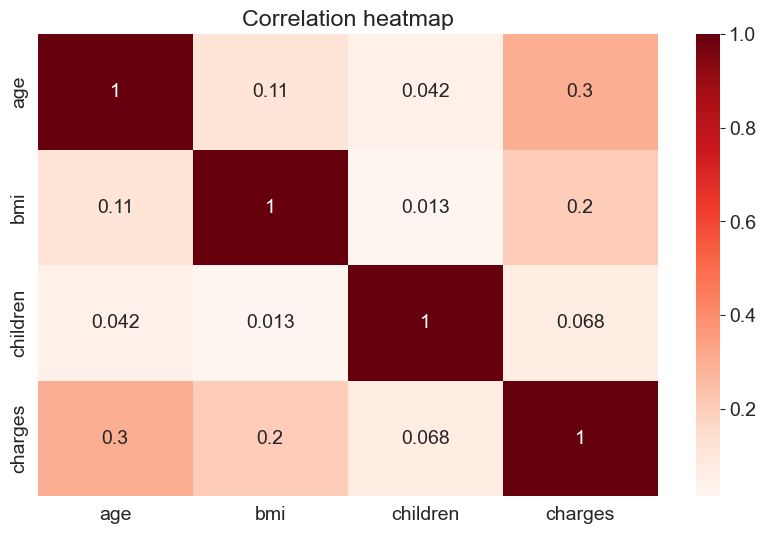

In [17]:
sns.heatmap(df.select_dtypes(include='number').corr(), cmap = "Reds", annot=True)
plt.title("Correlation heatmap")

##### Linear Regression using a Single Feature


In [18]:
non_somker_df = df[df['smoker'] == "no"]
non_somker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


Next, let's visualize the relationship between "age" and "charges"



In [19]:
fig = px.scatter(non_somker_df, x = "age", y = "charges", title= "Age vs Charges Distribution")
fig.show()

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the following formula:

y=wx+b

The line is characterized two numbers: 
w (called "slope") and 
b (called "intercept").

##### Model

In [20]:
def estimate_charges(age,w,c):
    return w*age + c

In [21]:
w = 50
c = 100
age = non_somker_df.age
estimate = estimate_charges(age,w,c)

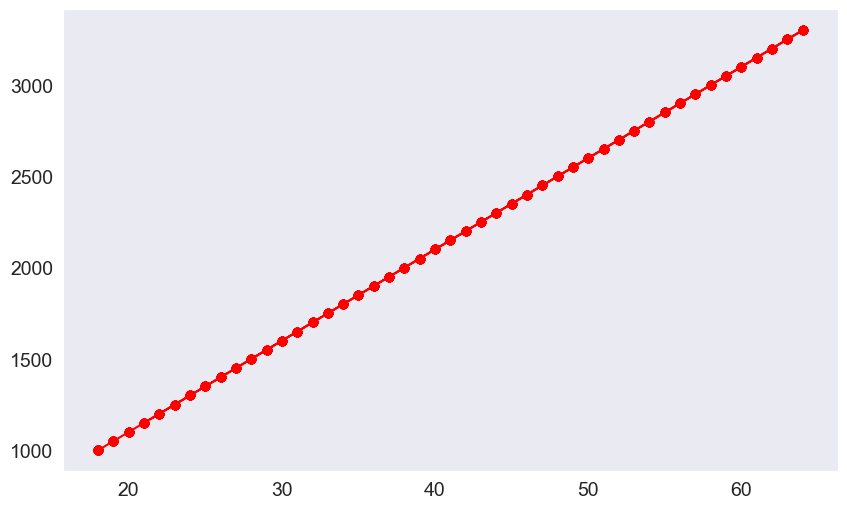

In [22]:
plt.plot(non_somker_df["age"],estimate, "r-o")

In [23]:
fig = px.scatter(non_somker_df, x = "age", y = "charges", title= "Age vs Charges Distribution")
fig.show()

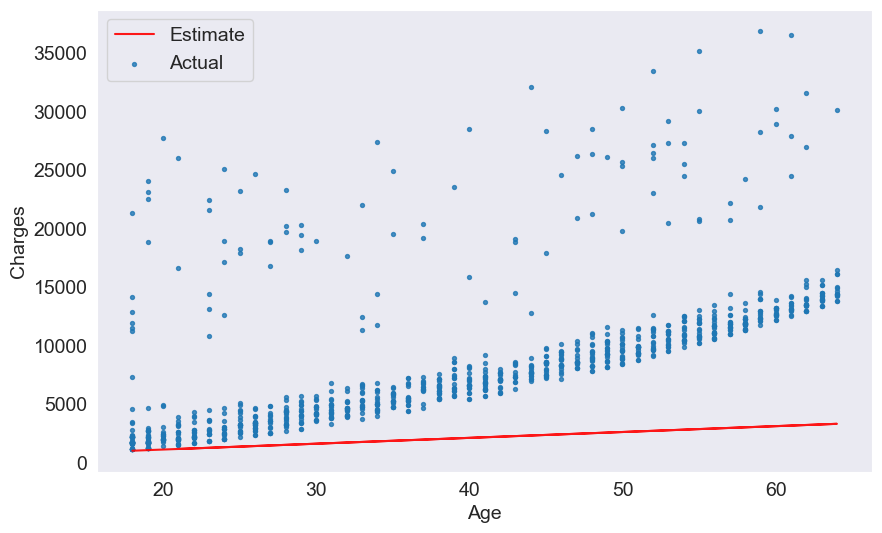

In [24]:
target = non_somker_df.charges

plt.plot(age, estimate, 'r', alpha=0.9)
plt.scatter(age, target, s=8,alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])


In [25]:
def add_parameters(w, b):
    target = non_somker_df.charges
    age = non_somker_df.age
    estimate = estimate_charges(age,w,b)
    plt.plot(age, estimate, 'r', alpha=0.9)
    plt.scatter(age, target, s=8,alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])



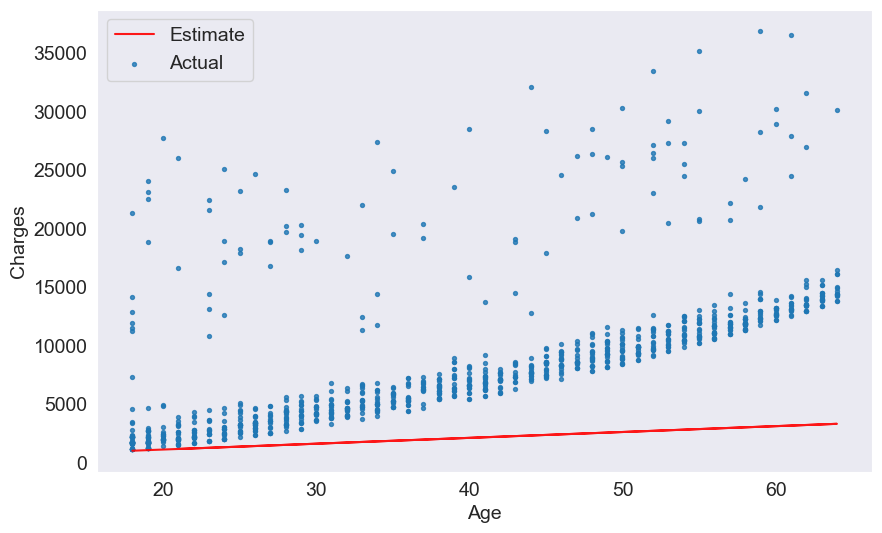

In [26]:
add_parameters(50,100)

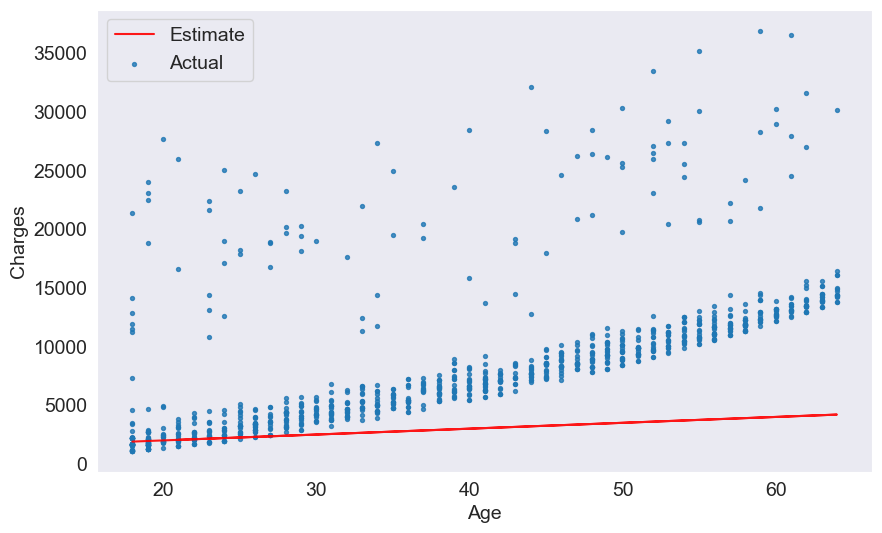

In [27]:
add_parameters(50,1000)

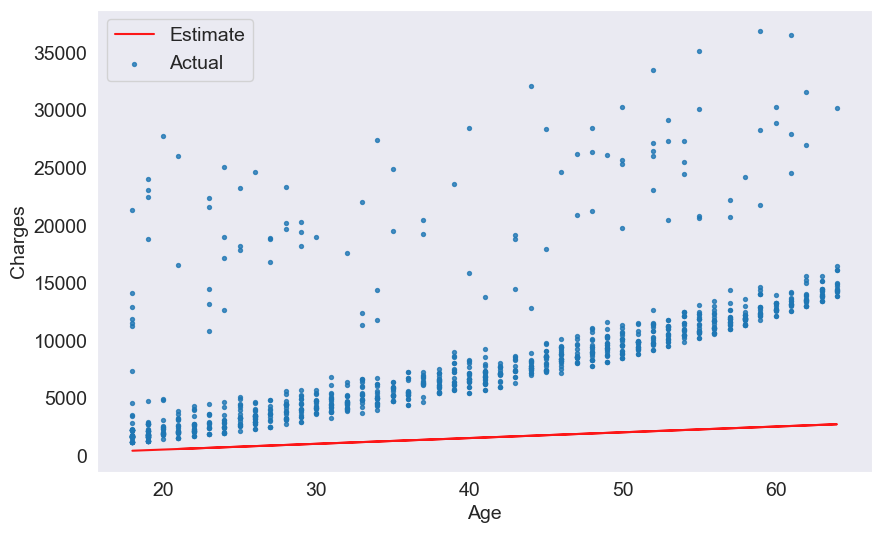

In [28]:
add_parameters(50,-500)

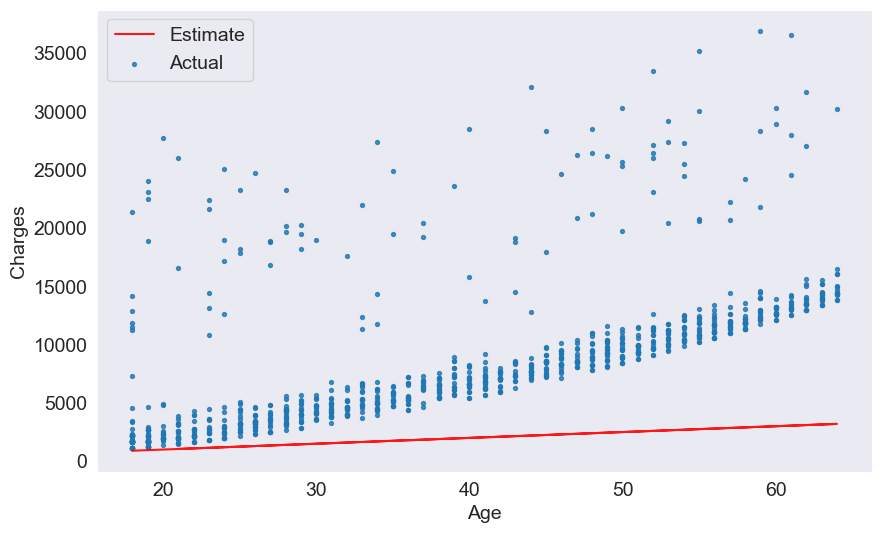

In [29]:
add_parameters(50, 0)

##### Loss/Cost Function


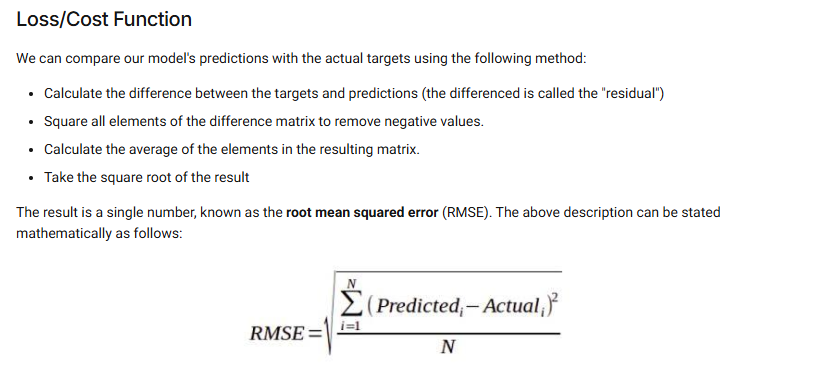

In [30]:
import numpy as np

In [31]:
def rmse(predicted, actual):
    return np.sqrt(np.mean(np.square(predicted - actual)))

In [32]:
estimate

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [33]:
non_somker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [34]:
rmse(estimate, non_somker_df.charges)

np.float64(8461.949562575493)

modifying try parameters functions

In [35]:
def add_parameters(w, b):
    target = non_somker_df.charges
    age = non_somker_df.age
    estimate = estimate_charges(age,w,b)
    plt.plot(age, estimate, 'r', alpha=0.9)
    plt.scatter(age, target, s=8,alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    print(f"RMSE Loss: {rmse(estimate, non_somker_df.charges)}")

RMSE Loss: 8461.949562575493


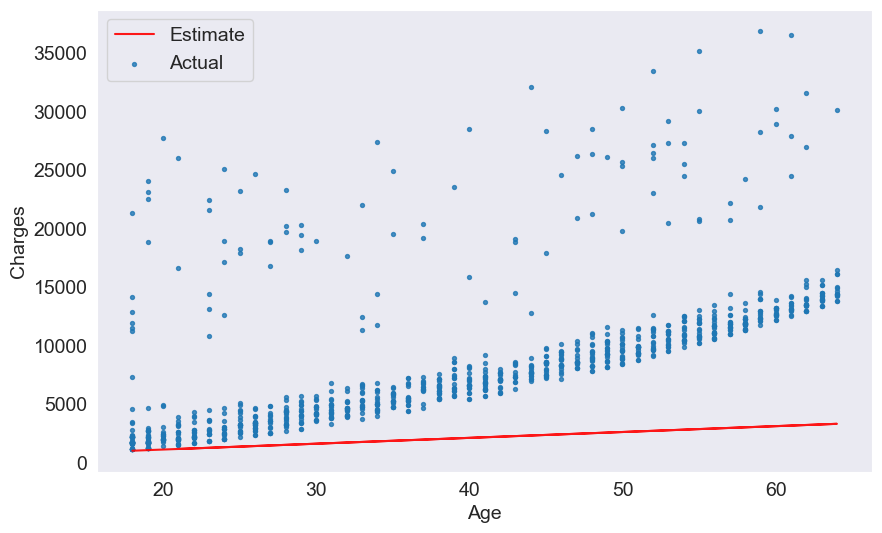

In [36]:
add_parameters(50,100)

### Linear Regression using sciket learn


In [37]:
from sklearn.linear_model import LinearRegression


In [38]:
model = LinearRegression()

In [39]:
model.fit(non_somker_df[['age']], non_somker_df['charges'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
model.predict([[23]])

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([4055.30443855])

In [41]:
prediction = model.predict(non_somker_df[["age"]])
prediction

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [42]:
rmse(prediction, target)

np.float64(4662.505766636395)

In the example where we created a model without sciket learn we used the linear equation: <br>
y = mx + c <br>
here m and c is represented by: 

In [43]:
# m
model.coef_

array([267.24891283])

In [44]:
# c
model.intercept_

np.float64(-2091.4205565650864)

RMSE Loss: 4662.505766636395


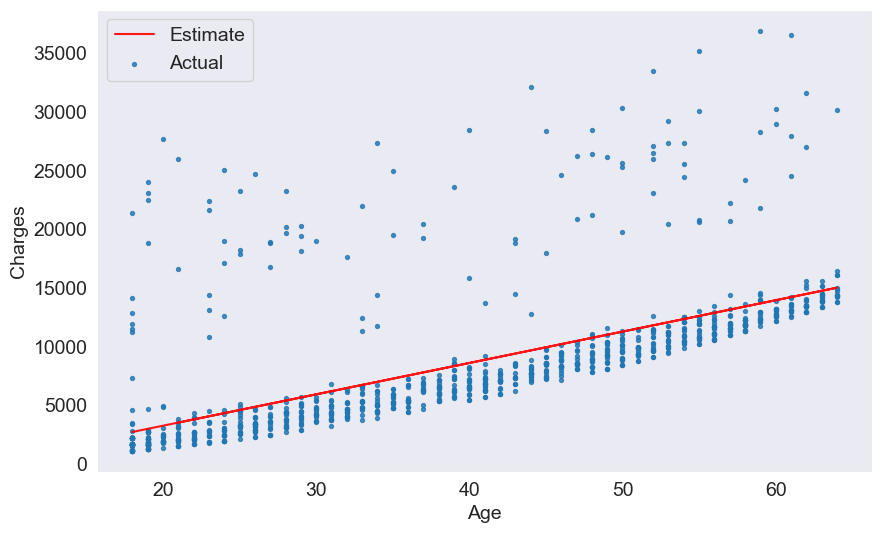

In [45]:
add_parameters(model.coef_,model.intercept_)

##### Summarizing the model in few lines


In [46]:
# Defining the input and expected result
inputs, result = non_somker_df[['age']], non_somker_df['charges'] 

# Choosing the model and fitting the data
model = LinearRegression().fit(inputs, result)

# predicting the result
prediction = model.predict(inputs)

# Calculating the loss
loss = rmse(prediction, non_somker_df['charges'])
print(f"Loss: {loss}")

Loss: 4662.505766636395


##### Linear Regression using Multiple Features


In [47]:
# Defining the input and expected result
inputs, result = non_somker_df[['age', 'bmi']], non_somker_df['charges'] 

# Choosing the model and fitting the data
model = LinearRegression().fit(inputs, result)

# predicting the result
prediction = model.predict(inputs)

# Calculating the loss
loss = rmse(prediction, non_somker_df['charges'])
print(f"Loss: {loss}")

Loss: 4662.3128354612945


As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.



In [48]:
non_somker_df.charges.corr(non_somker_df['bmi'])

np.float64(0.08403654312833271)

In [49]:
model.coef_ ,model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

In [50]:
# Defining the input and expected result
inputs, result = df[['age', 'bmi', 'children']], df['charges'] 

# Choosing the model and fitting the data
model = LinearRegression().fit(inputs, result)

# predicting the result
prediction = model.predict(inputs)

# Calculating the loss
loss = rmse(prediction, df['charges'])
print(f"Loss: {loss}")

Loss: 11355.317901125973


##### Making categories

##### Binary Relationship

In [51]:
smoker_code = {'yes' : 1, 'no' : 0}

In [52]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [53]:
df['smoker_code'] = df.smoker.map(smoker_code)

In [54]:
df.smoker_code.corr(df.charges)

np.float64(0.7872514304984778)

This shows that there is a string relationship between smoker code and charges


In [55]:
# Defining the input and expected result
inputs, result = df[['smoker_code']], df['charges'] 

# Choosing the model and fitting the data
model = LinearRegression().fit(inputs, result)

# predicting the result
prediction = model.predict(inputs)

# Calculating the loss
loss = rmse(prediction, df['charges'])
print(f"Loss: {loss}")

Loss: 7464.630999197846


##### One hot encoding

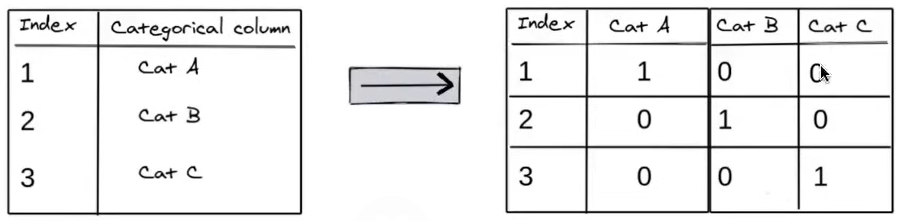

In [56]:
from sklearn import preprocessing

In [57]:
encode = preprocessing.OneHotEncoder()
encode.fit(df[["region"]])
encode.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [58]:
one_hot = encode.transform(df[["region"]]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [59]:
df[["northeast", "northwest", "southeast", "southwest"]] = one_hot

In [60]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0.0,0.0,0.0,1.0


In [61]:
df[['northeast', 'northwest', 'southeast', 'southwest']].corrwith(df['charges'])


northeast    0.006349
northwest   -0.039905
southeast    0.073982
southwest   -0.043210
dtype: float64

In [62]:
# Defining the input and expected result
inputs, result = df[['age', 'bmi', 'children', 'smoker_code', 'northeast', 'northwest', 'southeast', 'southwest']], df['charges'] 

# Choosing the model and fitting the data
model = LinearRegression().fit(inputs, result)

# predicting the result
prediction = model.predict(inputs)

# Calculating the loss
loss = rmse(prediction, df['charges'])
print(f"Loss: {loss}")

Loss: 6042.033215394104


In [63]:
model.predict([[10,21,2,1,0,0,0,1]])

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([21517.48210268])

##### Model improvement

Feature Scaling


In [64]:
model.coef_

array([  256.97358248,   338.66463761,   474.56646951, 23836.30050226,
         586.47922829,   234.2971161 ,  -447.88089913,  -372.89544526])

In [65]:
model.intercept_

np.float64(-12576.74910793317)

In [66]:
weighted_df= pd.DataFrame({
    "features" : np.append(np.array(['age', 'bmi', 'children', 'smoker_code', 'northeast', 'northwest', 'southeast', 'southwest']),1),
    "weight" : np.append(model.coef_, model.intercept_)
})
weighted_df

,features,weight
0,age,256.973582
1,bmi,338.664638
2,children,474.566470
3,smoker_code,23836.300502
4,northeast,586.479228
5,northwest,234.297116
6,southeast,-447.880899
7,southwest,-372.895445
8,1,-12576.749108


In [67]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df[['age', 'bmi', 'children']])
input_scaled = scaler.transform(df[['age', 'bmi', 'children']])
model = LinearRegression()
cat_data= df[['smoker_code', 'northeast', 'northwest', 'southeast', 'southwest']]
inputs = np.concatenate((input_scaled, cat_data), axis=1)
model.fit(inputs,df['charges'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
weighted_df= pd.DataFrame({
    "features" : np.append(['age', 'bmi', 'children']+['smoker_code', 'northeast', 'northwest', 'southeast', 'southwest'],1),
    "weight" : np.append(model.coef_, model.intercept_)
})
weighted_df.sort_values(by = 'weight', ascending=False)

,features,weight
3,smoker_code,23836.300502
8,1,8402.640125
0,age,3609.119197
1,bmi,2064.468352
4,northeast,586.479228
2,children,571.872609
5,northwest,234.297116
7,southwest,-372.895445
6,southeast,-447.880899


##### Creating test set

In [71]:
target = df['charges']

In [72]:
from sklearn.model_selection import train_test_split

input_train, input_test, target_train, target_test = train_test_split(inputs, target, test_size=0.2)

model = LinearRegression()
model.fit(input_train, target_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
predictions = model.predict(input_test)
predictions

array([ 7137.92200737,  1986.8399388 ,  -289.78327613,  7539.00733865,
        3398.75143678, 27884.12709693, 34257.05893636,  9683.64259534,
        7078.9525588 , 29045.3393934 , -1904.47208913, 15445.8819101 ,
        3693.36262111, 26215.55085601,  1805.38654441,  2858.47703738,
       33463.27116311, 10371.97673497,  6055.64078136,  -300.43935318,
        3465.4374409 , 15264.93018754,  8493.24789337,  -368.32258404,
        2498.05566692, 27213.96878099, 15773.20031426,  3515.69736918,
        9068.73365089, 28908.35176779,  -114.84920911,  9081.21914589,
         944.31535253,  7694.22645916, 11406.69597736, 33106.72431779,
        4659.89048874,  5236.3929705 ,  2604.81150772, 14279.5553391 ,
        2209.78342319,  6271.90200478, 10533.88644399,  2831.74981103,
        1401.21269223,  9654.33989462,  5902.06983437, -1027.62130936,
       40114.60047557,  5808.87872171,  5232.30718674, 11057.22615019,
        2789.08349714,  9309.64612306,  7787.90381314,  4338.25076338,
      

In [74]:
target_test

1174     4433.91590
816      2842.76075
1027    21595.38229
688     26236.57997
957     12609.88702
           ...     
95       3766.88380
1123    18903.49141
696     29186.48236
838      6402.29135
470      2497.03830
Name: charges, Length: 268, dtype: float64

In [76]:
rmse(predictions, target_test)

np.float64(5718.559638887522)